# 4.1 Subsection Figures and Tables used in LATEX

In [1]:
# Cell 0: imports & basic config

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import label
import heapq

# Optional: nicer plots
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)

# Path to your GEBCO subset used in Step 1 earlier
BATHY_FILE = (
    "/Users/abdellamohamed/projects/phd/src/"
    "voyage_optimization/submission_3/notebooks/arctic_routing_paperA/"
    "data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc"
)

# Routing grid resolution and domain (as used in the analysis)
RES_DEG = 0.5
LAT_MIN, LAT_MAX = 40.0, 85.0   # domain bounds
LON_MIN, LON_MAX = -20.0, 180.0

In [2]:
# Cell 1: load GEBCO subset and build routing grid

ds_bathy = xr.open_dataset(BATHY_FILE)

# Adjust variable names if different in your file
depth_var_name = "elevation"  # GEBCO uses 'elevation' with ocean as negative
lat_name = "lat"
lon_name = "lon"

depth_full = ds_bathy[depth_var_name].astype(float)
lat_full = ds_bathy[lat_name].values
lon_full = ds_bathy[lon_name].values

print("--- GEBCO subset summary ---")
print(ds_bathy)
print("\nLat range:", lat_full.min(), lat_full.max())
print("Lon range:", lon_full.min(), lon_full.max())

# Routing grid centres (same as we used before)
lats_rg = np.arange(40.5, 85.0, RES_DEG)   # 40.5 ... 84.5
lons_rg = np.arange(-19.5, 180.0, RES_DEG) # -19.5 ... 179.5

print("\nRouting grid:")
print("  n_lat =", len(lats_rg), "  range:", lats_rg[0], "to", lats_rg[-1])
print("  n_lon =", len(lons_rg), "  range:", lons_rg[0], "to", lons_rg[-1])

# Interpolate depth to routing grid
depth_rg_da = depth_full.interp(
    {lat_name: lats_rg, lon_name: lons_rg},
    method="linear"
)

depth_rg = depth_rg_da.values  # 2D [lat, lon], in metres (negative = sea)
print("\nRouting depth stats:")
print("  shape:", depth_rg.shape)
print("  min:", np.nanmin(depth_rg), "max:", np.nanmax(depth_rg))

--- GEBCO subset summary ---
<xarray.Dataset> Size: 1GB
Dimensions:    (lon: 48000, lat: 10800)
Coordinates:
  * lon        (lon) float64 384kB -20.0 -19.99 -19.99 ... 180.0 180.0 180.0
  * lat        (lat) float64 86kB 40.0 40.01 40.01 40.01 ... 84.99 84.99 85.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 1GB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:       

In [3]:
# Cell 2: land/sea mask and connected components

# Define sea as depth < 0 m
sea_mask_rg = depth_rg < 0.0
sea_frac = np.mean(sea_mask_rg)
land_frac = 1.0 - sea_frac

print("Sea fraction on routing grid:", sea_frac)
print("Land fraction on routing grid:", land_frac)

# Connected components on routing grid
structure = np.ones((3, 3), dtype=int)  # 8-connectivity
labels_rg, ncomp = label(sea_mask_rg.astype(int), structure=structure)

print("Number of sea components on routing grid:", ncomp)

# For convenience build lat/lon 2D arrays
lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

Sea fraction on routing grid: 0.48252654107178056
Land fraction on routing grid: 0.5174734589282195
Number of sea components on routing grid: 24


In [4]:
# Cell 3: A* implementation and canonical OD definition

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance between points (deg) in metres."""
    R = 6371.0e3
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = (np.sin(dphi/2)**2 +
         np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2)
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def astar_route(mask, si, sj, gi, gj, lats, lons):
    """
    A* on a boolean mask (True = traversable).
    Cost = haversine distance between grid-cell centres.
    """
    nlat, nlon = mask.shape
    if not (mask[si, sj] and mask[gi, gj]):
        return None

    # Precompute for speed
    lat_arr = lats
    lon_arr = lons

    # Heuristic: straight-line GC distance to goal
    def heuristic(i, j):
        return haversine(lat_arr[i], lon_arr[j],
                         lat_arr[gi], lon_arr[gj])

    # 8-neighbour moves
    neighbours = [(-1, 0), (1, 0), (0, -1), (0, 1),
                  (-1, -1), (-1, 1), (1, -1), (1, 1)]

    open_heap = []
    heapq.heappush(open_heap, (heuristic(si, sj), 0.0, (si, sj)))
    g_cost = {(si, sj): 0.0}
    came_from = {}

    visited = 0

    while open_heap:
        f, g, (i, j) = heapq.heappop(open_heap)
        visited += 1

        if (i, j) == (gi, gj):
            # Reconstruct path
            path = [(i, j)]
            while (i, j) in came_from:
                (i, j) = came_from[(i, j)]
                path.append((i, j))
            path.reverse()
            print(f"  A*: reached goal after visiting {visited} nodes.")
            return path

        for di, dj in neighbours:
            ni, nj = i + di, j + dj
            if not (0 <= ni < nlat and 0 <= nj < nlon):
                continue
            if not mask[ni, nj]:
                continue

            step_cost = haversine(lat_arr[i], lon_arr[j],
                                  lat_arr[ni], lon_arr[nj])
            ng = g + step_cost

            if (ni, nj) not in g_cost or ng < g_cost[(ni, nj)]:
                g_cost[(ni, nj)] = ng
                came_from[(ni, nj)] = (i, j)
                nf = ng + heuristic(ni, nj)
                heapq.heappush(open_heap, (nf, ng, (ni, nj)))

    print("  A*: no path found.")
    return None

# Canonical OD used in the analysis
start_lat0, start_lon0 = 40.5, -19.5
goal_lat0,  goal_lon0  = 69.5, 179.5

# Snap to grid (they are already on-grid, but we keep it general)
si = np.argmin(np.abs(lats_rg - start_lat0))
sj = np.argmin(np.abs(lons_rg - start_lon0))
gi = np.argmin(np.abs(lats_rg - goal_lat0))
gj = np.argmin(np.abs(lons_rg - goal_lon0))

print("Start index:", (si, sj), "->", lats_rg[si], lons_rg[sj])
print("Goal  index:", (gi, gj), "->", lats_rg[gi], lons_rg[gj])

# Great-circle distance between OD points
gc_m = haversine(start_lat0, start_lon0, goal_lat0, goal_lon0)
GC_NM = gc_m / 1852.0
print(f"Great-circle distance OD: {GC_NM:.1f} NM")

# Run sea-only route
print("\nRunning A* on sea_mask_rg ...")
path = astar_route(sea_mask_rg, si, sj, gi, gj, lats_rg, lons_rg)
if path is None:
    raise RuntimeError("Sea-only route not found; check mask/indices.")

path_arr = np.array(path)
pi = path_arr[:, 0]
pj = path_arr[:, 1]
lat_route = lats_rg[pi]
lon_route = lons_rg[pj]

# Route distance
dists = []
for k in range(1, len(lat_route)):
    d = haversine(lat_route[k-1], lon_route[k-1],
                  lat_route[k],   lon_route[k])
    dists.append(d)
total_m = np.sum(dists)
total_nm = total_m / 1852.0
ratio = total_nm / GC_NM

print(f"Sea-only route distance: {total_nm:.1f} NM")
print(f"Route / GC ratio: {ratio:.3f}")

Start index: (0, 0) -> 40.5 -19.5
Goal  index: (58, 398) -> 69.5 179.5
Great-circle distance OD: 4149.6 NM

Running A* on sea_mask_rg ...
  A*: reached goal after visiting 13561 nodes.
Sea-only route distance: 4561.1 NM
Route / GC ratio: 1.099


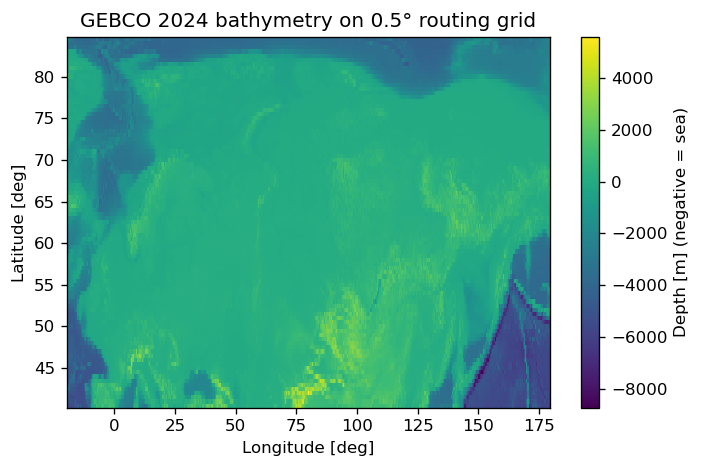

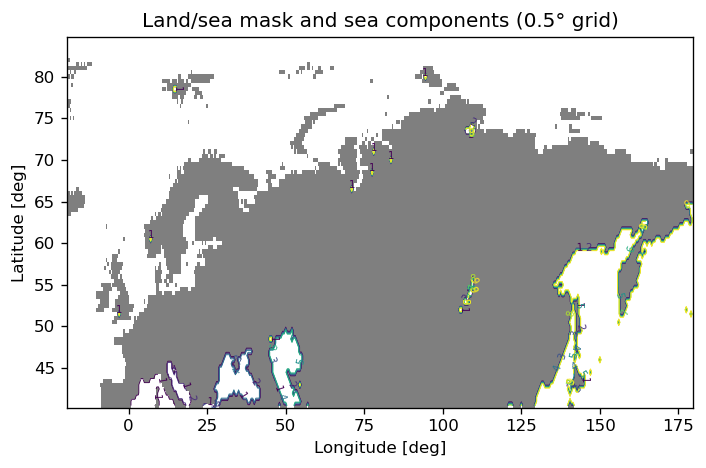

In [5]:
# Cell 4: Figure 1 - bathymetry and land/sea mask

# (a) Bathymetry on routing grid
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.pcolormesh(lon2d, lat2d, depth_rg,
                   shading="auto")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Depth [m] (negative = sea)")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("GEBCO 2024 bathymetry on 0.5° routing grid")
plt.tight_layout()
plt.show()

# (b) Land/sea mask with components (optional)
fig, ax = plt.subplots(figsize=(6, 4))
# Show land in light grey, sea in white, then overlay component labels in contour
ax.pcolormesh(lon2d, lat2d, ~sea_mask_rg,
              shading="auto", cmap="Greys", alpha=0.5)
cs = ax.contour(lon2d, lat2d, labels_rg,
                levels=np.arange(1, min(10, labels_rg.max()+1)),
                linewidths=0.5)
ax.clabel(cs, inline=True, fontsize=6, fmt="%d")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Land/sea mask and sea components (0.5° grid)")
plt.tight_layout()
plt.show()

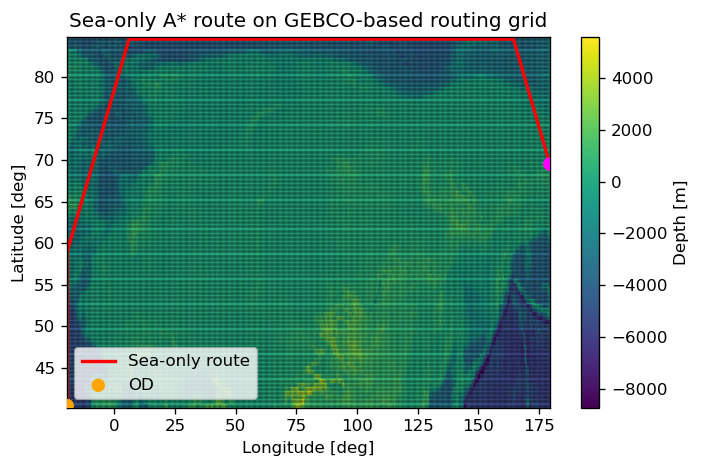

In [9]:
# Cell 5: Figure 2 - sea-only route over bathymetry

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.pcolormesh(lon2d, lat2d, depth_rg,
                   shading="auto")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Depth [m]")

# Grid cell centres (optional, can be removed if too busy)
ax.scatter(lon2d.flatten(), lat2d.flatten(),
           s=2, alpha=0.1, color="k")

# Sea-only route in red
ax.plot(lon_route, lat_route, "-r", lw=2, label="Sea-only route")

# Start/goal markers
ax.scatter([start_lon0, goal_lon0], [start_lat0, goal_lat0],
           c=["orange", "magenta"], s=50, marker="o", zorder=5,
           label="OD")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Sea-only A* route on GEBCO-based routing grid")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

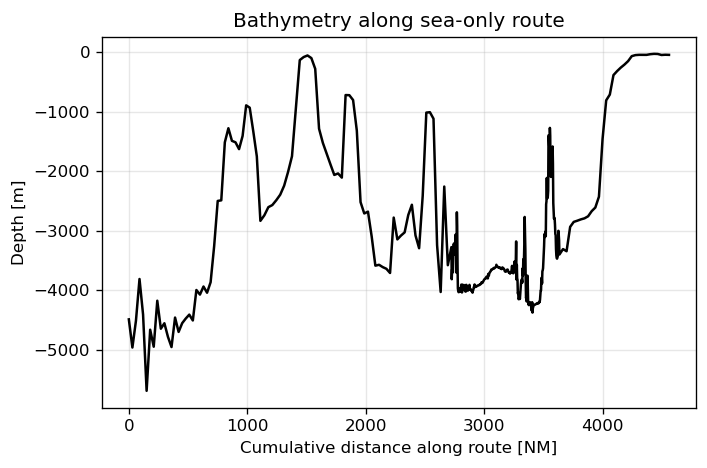

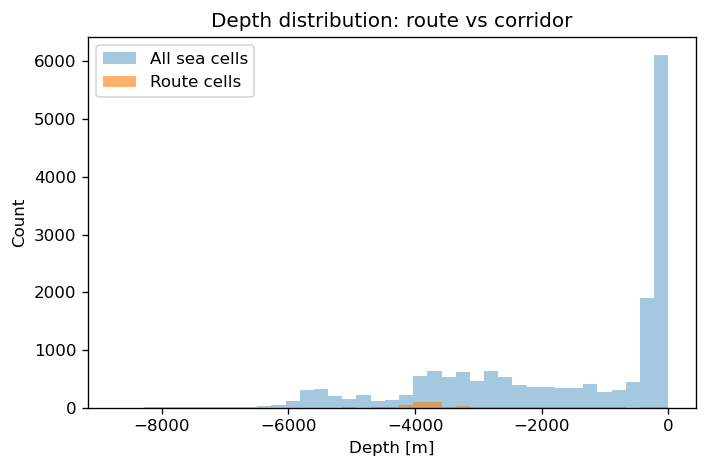

Depth along route [m]: min = -5684.5 mean = -3288.1422018348617 max = -29.0


In [10]:
# Cell 6: Figure S1 - depth along route and depth distribution

# (a) Depth profile along route
depth_route = depth_rg[pi, pj]  # depth along route (same shape as lat_route)

# Option 1: x-axis = cumulative distance
cum_dist_nm = np.insert(np.cumsum(np.array(dists) / 1852.0), 0, 0.0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cum_dist_nm, depth_route, "-k")
ax.set_xlabel("Cumulative distance along route [NM]")
ax.set_ylabel("Depth [m]")
ax.set_title("Bathymetry along sea-only route")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (b) Histogram of depths: route vs all sea cells
depth_sea = depth_rg[sea_mask_rg]

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(np.nanmin(depth_sea), 0.0, 40)

ax.hist(depth_sea, bins=bins, alpha=0.4, label="All sea cells")
ax.hist(depth_route, bins=bins, alpha=0.6, label="Route cells")

ax.set_xlabel("Depth [m]")
ax.set_ylabel("Count")
ax.set_title("Depth distribution: route vs corridor")
ax.legend()
plt.tight_layout()
plt.show()

print("Depth along route [m]: min =", depth_route.min(),
      "mean =", depth_route.mean(), "max =", depth_route.max())

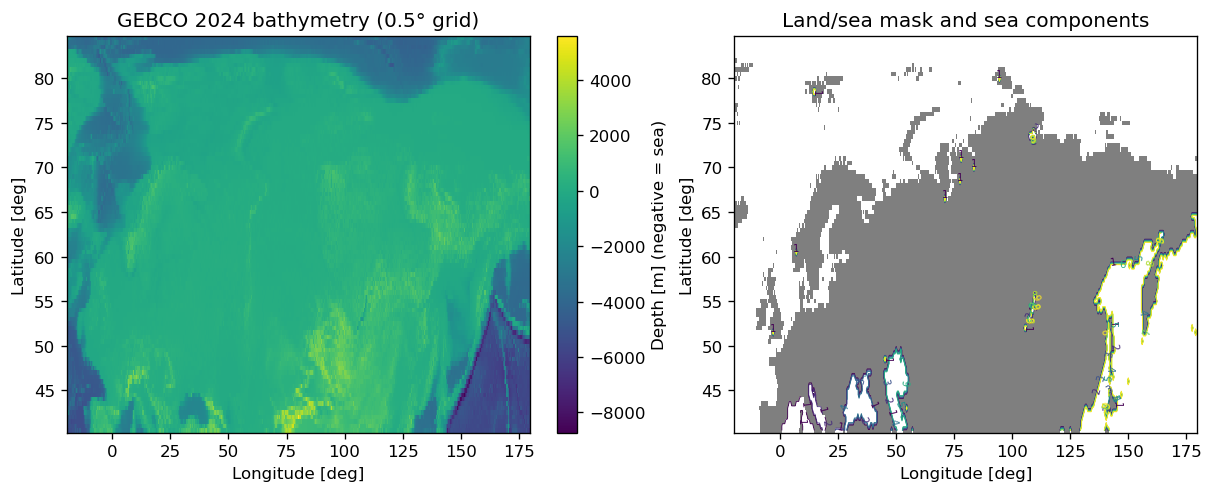

In [11]:
# === FIGURE 1: Bathymetry and land/sea mask ===

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# (a) Bathymetry on routing grid
ax = axes[0]
im = ax.pcolormesh(lon2d, lat2d, depth_rg,
                   shading="auto")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Depth [m] (negative = sea)")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("GEBCO 2024 bathymetry (0.5° grid)")

# (b) Land/sea mask + components
ax = axes[1]
ax.pcolormesh(lon2d, lat2d, ~sea_mask_rg,
              shading="auto", cmap="Greys", alpha=0.5)

# Optionally overlay only a few component labels (to avoid clutter)
cs = ax.contour(lon2d, lat2d, labels_rg,
                levels=np.arange(1, min(10, labels_rg.max() + 1)),
                linewidths=0.5)
ax.clabel(cs, inline=True, fontsize=6, fmt="%d")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Land/sea mask and sea components")

# Save + show
fig.savefig("fig01_bathy_domain_mask.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
fig.savefig("fig01_bathy_domain_mask.pdf", dpi=300, bbox_inches="tight")

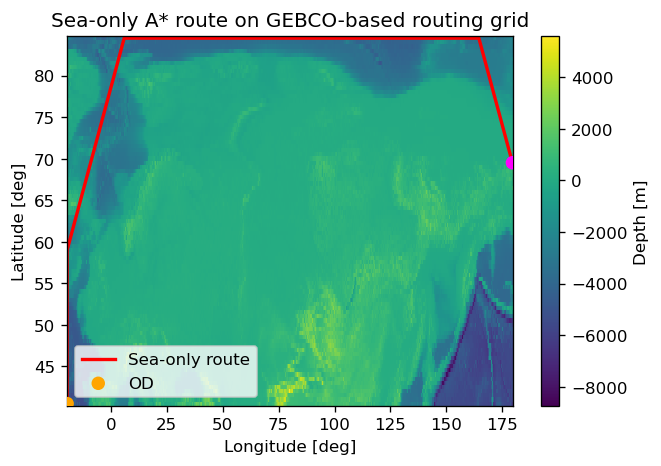

In [14]:
# === FIGURE 2: Sea-only route on bathymetry ===

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.pcolormesh(lon2d, lat2d, depth_rg,
                   shading="auto")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Depth [m]")

# Optional: show grid cell centres (comment out if too busy)
# ax.scatter(lon2d.flatten(), lat2d.flatten(),
#            s=2, alpha=0.1, color="k")

# Sea-only route in red
ax.plot(lon_route, lat_route, "-r", lw=2, label="Sea-only route")

# Start/goal markers
ax.scatter([start_lon0, goal_lon0],
           [start_lat0, goal_lat0],
           c=["orange", "magenta"],
           s=50, marker="o", zorder=5, label="OD")

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Sea-only A* route on GEBCO-based routing grid")
ax.legend(loc="lower left")

fig.savefig("fig02_seaonly_route.png", dpi=300, bbox_inches="tight")
plt.show()

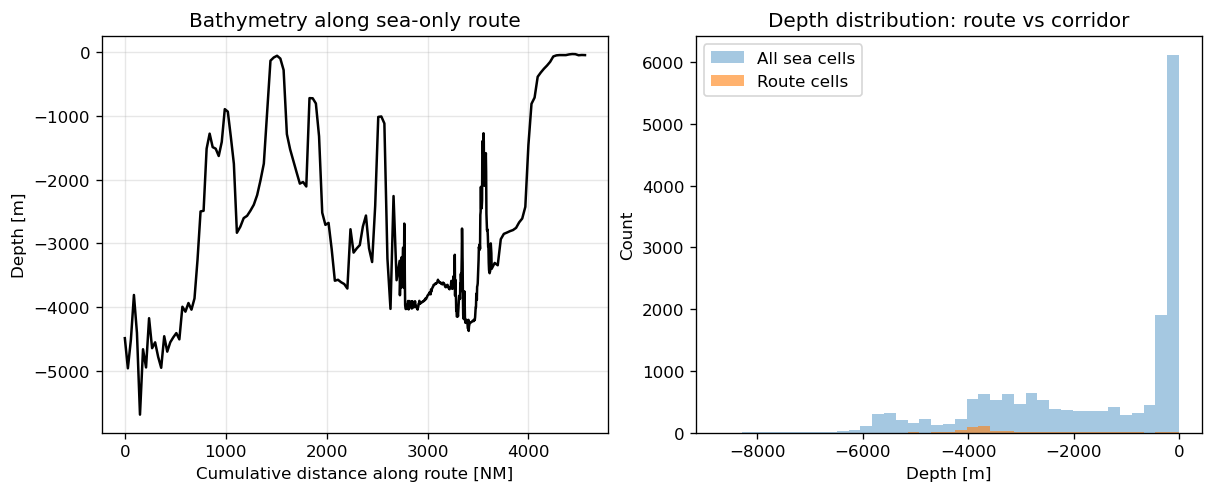

Depth along route [m]: min = -5684.5 mean = -3288.1422018348617 max = -29.0


In [15]:
# === FIGURE S1: Depth along route and depth distribution ===

# (Ensure these exist:)
# depth_route = depth_rg[pi, pj]
# depth_sea   = depth_rg[sea_mask_rg]
# cum_dist_nm = np.insert(np.cumsum(np.array(dists) / 1852.0), 0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# (a) Depth profile along route
ax = axes[0]
ax.plot(cum_dist_nm, depth_route, "-k")
ax.set_xlabel("Cumulative distance along route [NM]")
ax.set_ylabel("Depth [m]")
ax.set_title("Bathymetry along sea-only route")
ax.grid(True, alpha=0.3)

# (b) Histogram: route vs all sea
ax = axes[1]
bins = np.linspace(np.nanmin(depth_sea), 0.0, 40)

ax.hist(depth_sea,  bins=bins, alpha=0.4, label="All sea cells")
ax.hist(depth_route, bins=bins, alpha=0.6, label="Route cells")

ax.set_xlabel("Depth [m]")
ax.set_ylabel("Count")
ax.set_title("Depth distribution: route vs corridor")
ax.legend()

fig.savefig("figS1_depth_along_route.png", dpi=300, bbox_inches="tight")
plt.show()

print("Depth along route [m]: min =", depth_route.min(),
      "mean =", depth_route.mean(), "max =", depth_route.max())